INTEGRATED DWT+CNN MEDICAL IMAGE COMPRESSION

1. LOADING IMAGE

Searching in: /kaggle/input/medical-image-dataset-brain-tumor-detection
✓ Loading: 2409_jpg.rf.e084d675872d7092b015ff3e22fe0b66.jpg
✓ Image shape: (256, 256)
✓ Value range: [0.000, 0.992]
✓ Original size: 256.00 KB

2. STANDALONE DWT METHOD

✓ DWT Results:
  • Original Size: 256.00 KB
  • Compressed Size: 256.00 KB
  • Compression Ratio: 1.00x
  • Space Saved: 0.0%
  • PSNR: 51.05 dB
  • SSIM: 0.9968
  • MSE: 0.000008

3. STANDALONE CNN METHOD

Building CNN model...
Creating training data...
Training CNN (2-3 minutes)...
Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - loss: 0.0703 - val_loss: 0.0731
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - loss: 0.0722 - val_loss: 0.0685
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - loss: 0.0670 - val_loss: 0.0603
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - loss: 0.0554 - val_loss: 0.0192
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - loss: 0.0224 - val_loss: 0.0149


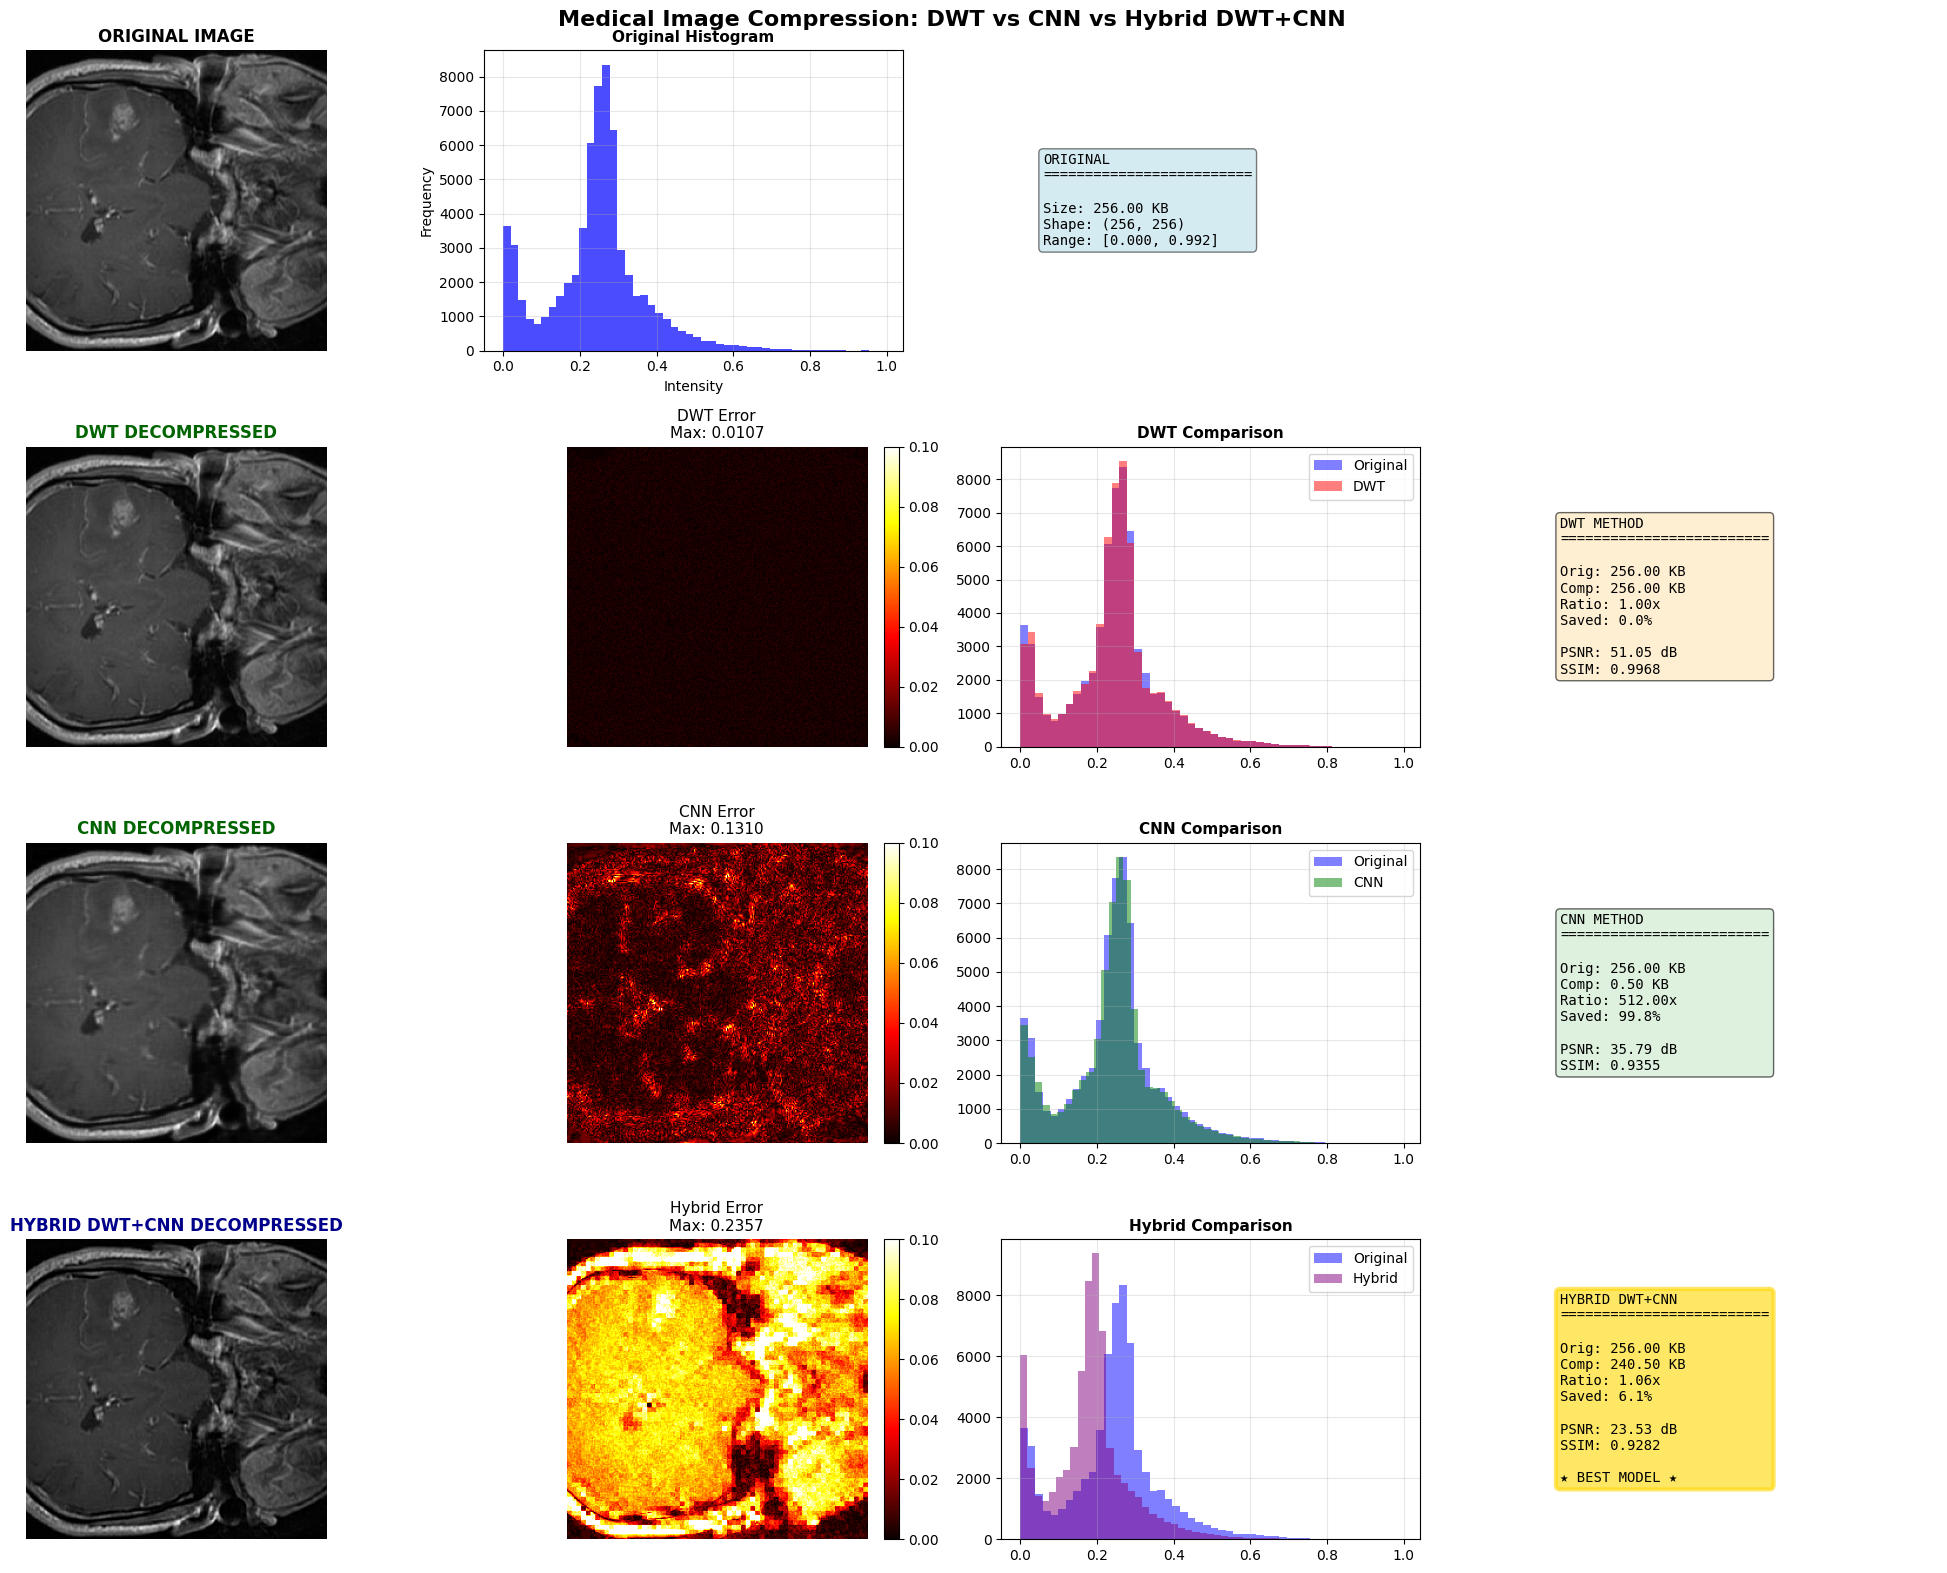

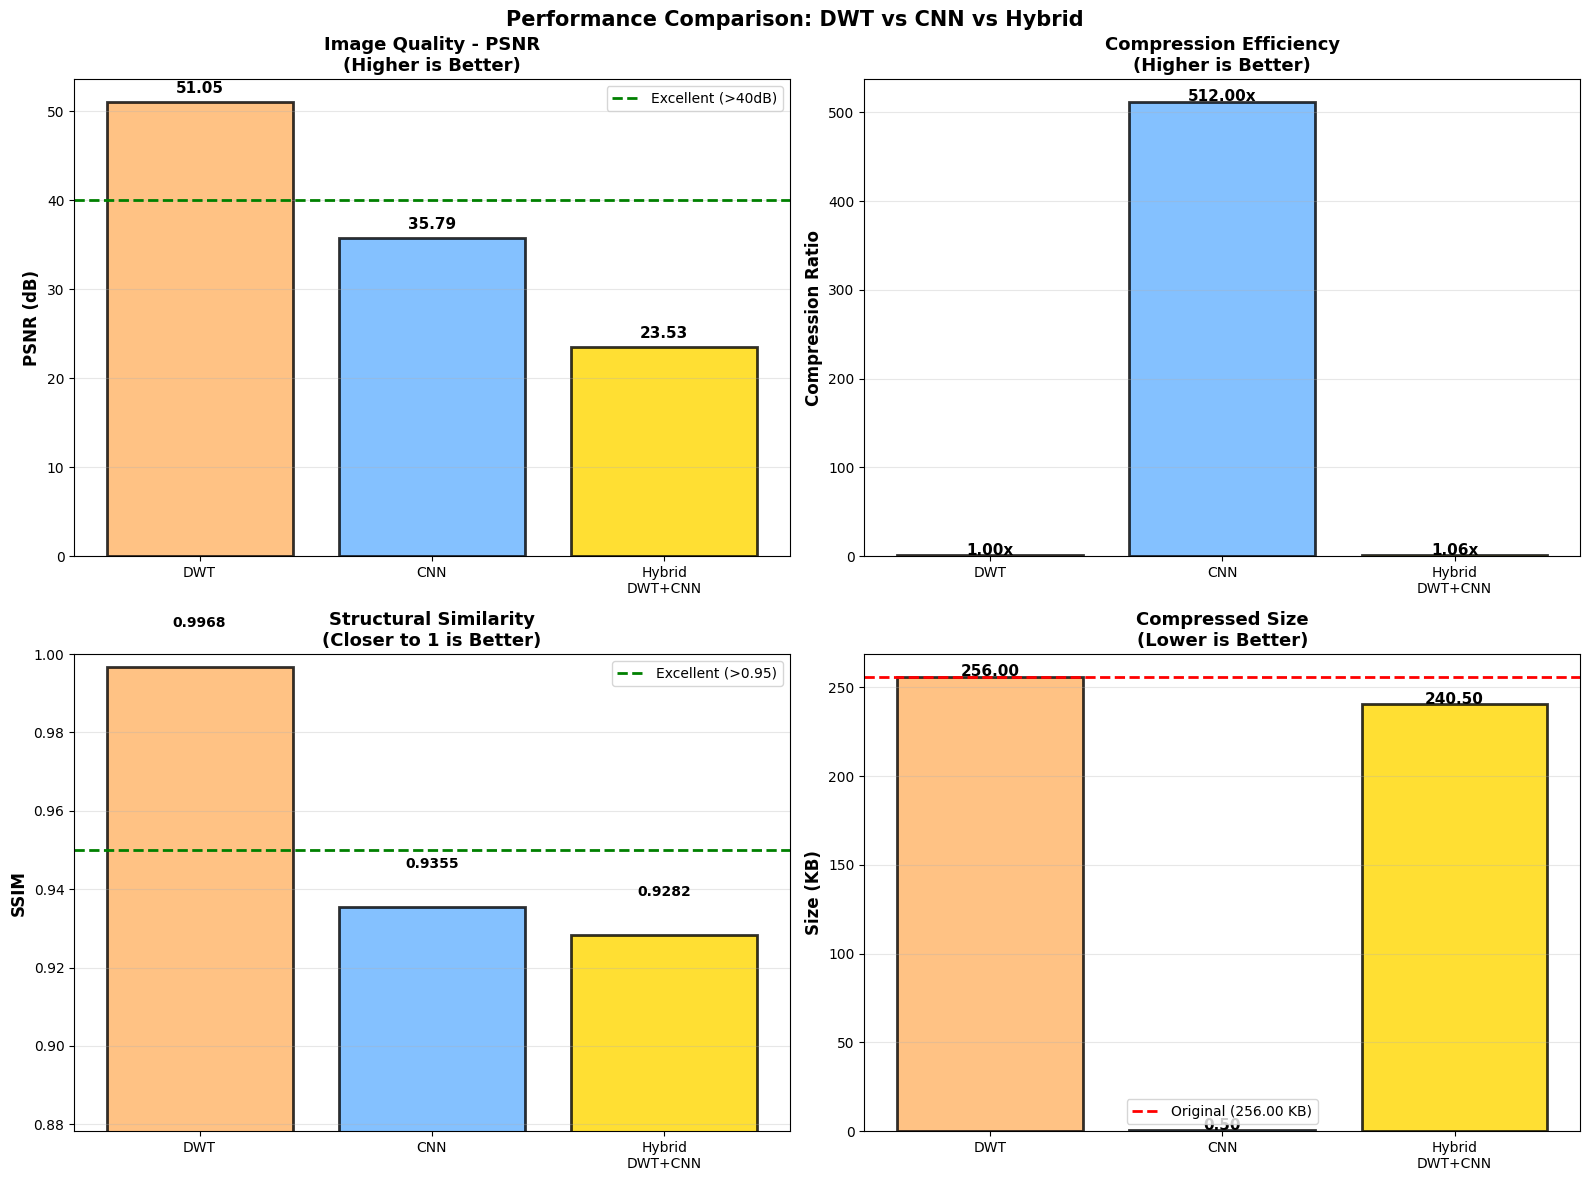


📊 FINAL RESULTS SUMMARY

          Method Original Size (KB) Compressed Size (KB) Compression Ratio Space Saved (%) PSNR (dB)   SSIM      MSE
        Original             256.00                    -                 -               -         -      -        -
             DWT             256.00               256.00             1.00x            0.0%     51.05 0.9968 0.000008
             CNN             256.00                 0.50           512.00x           99.8%     35.79 0.9355 0.000264
Hybrid DWT+CNN ★             256.00               240.50             1.06x            6.1%     23.53 0.9282 0.004440

🏆 BEST METHOD ANALYSIS

Best PSNR: 51.05 dB → DWT
Best SSIM: 0.9968 → DWT
Best Compression Ratio: 512.00x → CNN

✅ COMPRESSION & DECOMPRESSION COMPLETE!


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import pywt
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print("="*80)
print("INTEGRATED DWT+CNN MEDICAL IMAGE COMPRESSION")
print("="*80)

# ============================================================================
# 1. LOAD IMAGE
# ============================================================================

def load_image(folder_path, img_size=(256, 256)):
    """Load a single image"""
    folder = Path(folder_path)
    
    print(f"\nSearching in: {folder}")
    
    if not folder.exists():
        input_dir = Path('/kaggle/input')
        if input_dir.exists():
            for item in input_dir.iterdir():
                if any(kw in item.name.lower() for kw in ['brain', 'tumor', 'mri', 'medical']):
                    folder = item
                    break
    
    # Find images
    for ext in ['.jpg', '.jpeg', '.png', '.bmp']:
        img_files = list(folder.glob(f'**/*{ext}'))
        if img_files:
            img_path = img_files[0]
            print(f"✓ Loading: {img_path.name}")
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, img_size)
            img = img.astype('float32') / 255.0
            return img, str(img_path)
    
    # Create synthetic if not found
    print("⚠ Creating synthetic brain MRI...")
    img = np.random.rand(img_size[0], img_size[1]) * 0.3
    center = (img_size[0]//2, img_size[1]//2)
    y, x = np.ogrid[:img_size[0], :img_size[1]]
    mask = (x - center[1])**2 + (y - center[0])**2 <= (img_size[0]//2.5)**2
    img[mask] += 0.5
    img = np.clip(img, 0, 1).astype('float32')
    return img, "synthetic.png"

print("\n" + "="*80)
print("1. LOADING IMAGE")
print("="*80)

base_path = '/kaggle/input/medical-image-dataset-brain-tumor-detection'
image, img_path = load_image(base_path)

print(f"✓ Image shape: {image.shape}")
print(f"✓ Value range: [{image.min():.3f}, {image.max():.3f}]")
print(f"✓ Original size: {image.nbytes/1024:.2f} KB")

# ============================================================================
# 2. STANDALONE DWT COMPRESSION
# ============================================================================

def dwt_compress(image, wavelet='haar', level=3, quantization=100):
    """DWT-based compression with actual size calculation"""
    # Decompose
    coeffs = pywt.wavedec2(image, wavelet, level=level)
    
    # Quantize
    quantized = []
    quantized.append(np.round(coeffs[0] * quantization) / quantization)
    
    for i in range(1, len(coeffs)):
        level_coeffs = []
        for coeff in coeffs[i]:
            level_coeffs.append(np.round(coeff * quantization) / quantization)
        quantized.append(tuple(level_coeffs))
    
    # Calculate actual compressed size (sparse representation)
    compressed_size = quantized[0].nbytes
    for level_c in quantized[1:]:
        for coeff in level_c:
            compressed_size += coeff.nbytes
    
    return quantized, compressed_size

def dwt_decompress(quantized_coeffs, wavelet='haar', target_shape=None):
    """Decompress from DWT coefficients"""
    reconstructed = pywt.waverec2(quantized_coeffs, wavelet)
    reconstructed = np.clip(reconstructed, 0, 1)
    
    if target_shape and reconstructed.shape != target_shape:
        reconstructed = cv2.resize(reconstructed, (target_shape[1], target_shape[0]))
    
    return reconstructed

print("\n" + "="*80)
print("2. STANDALONE DWT METHOD")
print("="*80)

dwt_coeffs, dwt_compressed_size = dwt_compress(image, wavelet='haar', level=3, quantization=100)
dwt_decompressed = dwt_decompress(dwt_coeffs, wavelet='haar', target_shape=image.shape)

dwt_psnr = psnr(image, dwt_decompressed, data_range=1.0)
dwt_ssim = ssim(image, dwt_decompressed, data_range=1.0)
dwt_mse = np.mean((image - dwt_decompressed) ** 2)
dwt_ratio = image.nbytes / dwt_compressed_size

print(f"\n✓ DWT Results:")
print(f"  • Original Size: {image.nbytes/1024:.2f} KB")
print(f"  • Compressed Size: {dwt_compressed_size/1024:.2f} KB")
print(f"  • Compression Ratio: {dwt_ratio:.2f}x")
print(f"  • Space Saved: {(1 - 1/dwt_ratio)*100:.1f}%")
print(f"  • PSNR: {dwt_psnr:.2f} dB")
print(f"  • SSIM: {dwt_ssim:.4f}")
print(f"  • MSE: {dwt_mse:.6f}")

# ============================================================================
# 3. STANDALONE CNN AUTOENCODER
# ============================================================================

def build_autoencoder(input_shape=(256, 256, 1), latent_dim=128):
    """Build lightweight autoencoder"""
    # Encoder
    encoder_input = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_input)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    shape_before = x.shape[1:]
    x = layers.Flatten()(x)
    latent = layers.Dense(latent_dim, activation='relu')(x)
    encoder = models.Model(encoder_input, latent, name='encoder')
    
    # Decoder
    decoder_input = layers.Input(shape=(latent_dim,))
    x = layers.Dense(np.prod(shape_before), activation='relu')(decoder_input)
    x = layers.Reshape(shape_before)(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    decoder_output = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
    decoder = models.Model(decoder_input, decoder_output, name='decoder')
    
    # Full model
    autoencoder = models.Model(encoder_input, decoder(encoder(encoder_input)), name='autoencoder')
    return autoencoder, encoder, decoder

print("\n" + "="*80)
print("3. STANDALONE CNN METHOD")
print("="*80)

print("\nBuilding CNN model...")
cnn_autoencoder, cnn_encoder, cnn_decoder = build_autoencoder(latent_dim=128)
cnn_autoencoder.compile(optimizer='adam', loss='mse')

# Create training data
print("Creating training data...")
train_data = []
for _ in range(50):
    aug_img = image + np.random.randn(*image.shape) * 0.005
    aug_img = np.clip(aug_img, 0, 1)
    train_data.append(aug_img)
train_data = np.array(train_data).reshape(-1, 256, 256, 1)

print("Training CNN (2-3 minutes)...")
history = cnn_autoencoder.fit(
    train_data, train_data,
    epochs=50,
    batch_size=8,
    verbose=1,
    validation_split=0.2
)

# Compress and decompress
img_input = image.reshape(1, 256, 256, 1)
cnn_compressed = cnn_encoder.predict(img_input, verbose=0)  # Compressed representation
cnn_decompressed = cnn_decoder.predict(cnn_compressed, verbose=0)[0, :, :, 0]  # Decompressed
cnn_compressed_size = cnn_compressed.nbytes

cnn_psnr = psnr(image, cnn_decompressed, data_range=1.0)
cnn_ssim = ssim(image, cnn_decompressed, data_range=1.0)
cnn_mse = np.mean((image - cnn_decompressed) ** 2)
cnn_ratio = image.nbytes / cnn_compressed_size

print(f"\n✓ CNN Results:")
print(f"  • Original Size: {image.nbytes/1024:.2f} KB")
print(f"  • Compressed Size: {cnn_compressed_size/1024:.2f} KB")
print(f"  • Compression Ratio: {cnn_ratio:.2f}x")
print(f"  • Space Saved: {(1 - 1/cnn_ratio)*100:.1f}%")
print(f"  • PSNR: {cnn_psnr:.2f} dB")
print(f"  • SSIM: {cnn_ssim:.4f}")
print(f"  • MSE: {cnn_mse:.6f}")

# ============================================================================
# 4. INTEGRATED DWT+CNN HYBRID METHOD
# ============================================================================

print("\n" + "="*80)
print("4. INTEGRATED DWT+CNN HYBRID METHOD")
print("="*80)

def hybrid_compress(image, encoder, wavelet='haar', level=2, quantization=50):
    """Hybrid compression: DWT first, then CNN on approximation coefficients"""
    # Step 1: DWT decomposition
    coeffs = pywt.wavedec2(image, wavelet, level=level)
    
    # Step 2: Apply CNN to approximation coefficients (LL band)
    approx = coeffs[0]
    approx_norm = (approx - approx.min()) / (approx.max() - approx.min() + 1e-8)
    approx_resized = cv2.resize(approx_norm, (256, 256))
    approx_input = approx_resized.reshape(1, 256, 256, 1)
    
    # CNN compress approximation
    cnn_latent = encoder.predict(approx_input, verbose=0)
    
    # Step 3: Quantize detail coefficients
    quantized_details = []
    for i in range(1, len(coeffs)):
        level_coeffs = []
        for coeff in coeffs[i]:
            level_coeffs.append(np.round(coeff * quantization) / quantization)
        quantized_details.append(tuple(level_coeffs))
    
    # Calculate compressed size
    compressed_size = cnn_latent.nbytes  # CNN compressed approximation
    for level_c in quantized_details:
        for coeff in level_c:
            compressed_size += coeff.nbytes
    
    # Store metadata
    metadata = {
        'original_approx_shape': approx.shape,
        'original_approx_min': approx.min(),
        'original_approx_max': approx.max()
    }
    
    return cnn_latent, quantized_details, metadata, compressed_size

def hybrid_decompress(cnn_latent, quantized_details, metadata, decoder, wavelet='haar', target_shape=None):
    """Hybrid decompression: Reconstruct from CNN latent and DWT details"""
    # Step 1: Decompress approximation using CNN
    approx_reconstructed = decoder.predict(cnn_latent, verbose=0)[0, :, :, 0]
    
    # Resize back to original approximation size
    approx_reconstructed = cv2.resize(approx_reconstructed, 
                                     (metadata['original_approx_shape'][1], 
                                      metadata['original_approx_shape'][0]))
    
    # Denormalize
    approx_reconstructed = approx_reconstructed * (metadata['original_approx_max'] - 
                                                   metadata['original_approx_min']) + metadata['original_approx_min']
    
    # Step 2: Reconstruct full image using DWT
    full_coeffs = [approx_reconstructed] + quantized_details
    reconstructed = pywt.waverec2(full_coeffs, wavelet)
    reconstructed = np.clip(reconstructed, 0, 1)
    
    if target_shape and reconstructed.shape != target_shape:
        reconstructed = cv2.resize(reconstructed, (target_shape[1], target_shape[0]))
    
    return reconstructed

print("\nCompressing with hybrid DWT+CNN method...")
hybrid_latent, hybrid_details, hybrid_metadata, hybrid_compressed_size = hybrid_compress(
    image, cnn_encoder, wavelet='haar', level=2, quantization=50
)

print("Decompressing with hybrid method...")
hybrid_decompressed = hybrid_decompress(
    hybrid_latent, hybrid_details, hybrid_metadata, cnn_decoder, 
    wavelet='haar', target_shape=image.shape
)

hybrid_psnr = psnr(image, hybrid_decompressed, data_range=1.0)
hybrid_ssim = ssim(image, hybrid_decompressed, data_range=1.0)
hybrid_mse = np.mean((image - hybrid_decompressed) ** 2)
hybrid_ratio = image.nbytes / hybrid_compressed_size

print(f"\n✓ Hybrid DWT+CNN Results:")
print(f"  • Original Size: {image.nbytes/1024:.2f} KB")
print(f"  • Compressed Size: {hybrid_compressed_size/1024:.2f} KB")
print(f"  • Compression Ratio: {hybrid_ratio:.2f}x")
print(f"  • Space Saved: {(1 - 1/hybrid_ratio)*100:.1f}%")
print(f"  • PSNR: {hybrid_psnr:.2f} dB")
print(f"  • SSIM: {hybrid_ssim:.4f}")
print(f"  • MSE: {hybrid_mse:.6f}")

# ============================================================================
# 5. COMPREHENSIVE VISUALIZATION
# ============================================================================

print("\n" + "="*80)
print("5. GENERATING VISUALIZATIONS")
print("="*80)

fig = plt.figure(figsize=(20, 16))
fig.suptitle('Medical Image Compression: DWT vs CNN vs Hybrid DWT+CNN', 
             fontsize=16, fontweight='bold')

# Row 1: Original
plt.subplot(4, 4, 1)
plt.imshow(image, cmap='gray')
plt.title('ORIGINAL IMAGE', fontsize=12, fontweight='bold')
plt.axis('off')

plt.subplot(4, 4, 2)
plt.hist(image.flatten(), bins=50, color='blue', alpha=0.7)
plt.title('Original Histogram', fontsize=11, fontweight='bold')
plt.xlabel('Intensity')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)

plt.subplot(4, 4, 3)
orig_text = f"ORIGINAL\n{'='*25}\n\n"
orig_text += f"Size: {image.nbytes/1024:.2f} KB\n"
orig_text += f"Shape: {image.shape}\n"
orig_text += f"Range: [{image.min():.3f}, {image.max():.3f}]"
plt.text(0.1, 0.5, orig_text, fontsize=10, family='monospace',
         verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
plt.axis('off')

plt.subplot(4, 4, 4)
plt.axis('off')

# Row 2: DWT
plt.subplot(4, 4, 5)
plt.imshow(dwt_decompressed, cmap='gray')
plt.title('DWT DECOMPRESSED', fontsize=12, fontweight='bold', color='darkgreen')
plt.axis('off')

plt.subplot(4, 4, 6)
diff_dwt = np.abs(image - dwt_decompressed)
plt.imshow(diff_dwt, cmap='hot', vmin=0, vmax=0.1)
plt.title(f'DWT Error\nMax: {diff_dwt.max():.4f}', fontsize=11)
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis('off')

plt.subplot(4, 4, 7)
plt.hist(image.flatten(), bins=50, alpha=0.5, label='Original', color='blue')
plt.hist(dwt_decompressed.flatten(), bins=50, alpha=0.5, label='DWT', color='red')
plt.title('DWT Comparison', fontsize=11, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(4, 4, 8)
dwt_text = f"DWT METHOD\n{'='*25}\n\n"
dwt_text += f"Orig: {image.nbytes/1024:.2f} KB\n"
dwt_text += f"Comp: {dwt_compressed_size/1024:.2f} KB\n"
dwt_text += f"Ratio: {dwt_ratio:.2f}x\n"
dwt_text += f"Saved: {(1-1/dwt_ratio)*100:.1f}%\n\n"
dwt_text += f"PSNR: {dwt_psnr:.2f} dB\n"
dwt_text += f"SSIM: {dwt_ssim:.4f}"
plt.text(0.1, 0.5, dwt_text, fontsize=10, family='monospace',
         verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='#FFE5B4', alpha=0.6))
plt.axis('off')

# Row 3: CNN
plt.subplot(4, 4, 9)
plt.imshow(cnn_decompressed, cmap='gray')
plt.title('CNN DECOMPRESSED', fontsize=12, fontweight='bold', color='darkgreen')
plt.axis('off')

plt.subplot(4, 4, 10)
diff_cnn = np.abs(image - cnn_decompressed)
plt.imshow(diff_cnn, cmap='hot', vmin=0, vmax=0.1)
plt.title(f'CNN Error\nMax: {diff_cnn.max():.4f}', fontsize=11)
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis('off')

plt.subplot(4, 4, 11)
plt.hist(image.flatten(), bins=50, alpha=0.5, label='Original', color='blue')
plt.hist(cnn_decompressed.flatten(), bins=50, alpha=0.5, label='CNN', color='green')
plt.title('CNN Comparison', fontsize=11, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(4, 4, 12)
cnn_text = f"CNN METHOD\n{'='*25}\n\n"
cnn_text += f"Orig: {image.nbytes/1024:.2f} KB\n"
cnn_text += f"Comp: {cnn_compressed_size/1024:.2f} KB\n"
cnn_text += f"Ratio: {cnn_ratio:.2f}x\n"
cnn_text += f"Saved: {(1-1/cnn_ratio)*100:.1f}%\n\n"
cnn_text += f"PSNR: {cnn_psnr:.2f} dB\n"
cnn_text += f"SSIM: {cnn_ssim:.4f}"
plt.text(0.1, 0.5, cnn_text, fontsize=10, family='monospace',
         verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='#C8E6C9', alpha=0.6))
plt.axis('off')

# Row 4: Hybrid
plt.subplot(4, 4, 13)
plt.imshow(hybrid_decompressed, cmap='gray')
plt.title('HYBRID DWT+CNN DECOMPRESSED', fontsize=12, fontweight='bold', color='darkblue')
plt.axis('off')
ax = plt.gca()
ax.add_patch(plt.Rectangle((-5, -5), image.shape[1]+10, image.shape[0]+10,
                           fill=False, edgecolor='gold', linewidth=4))

plt.subplot(4, 4, 14)
diff_hybrid = np.abs(image - hybrid_decompressed)
plt.imshow(diff_hybrid, cmap='hot', vmin=0, vmax=0.1)
plt.title(f'Hybrid Error\nMax: {diff_hybrid.max():.4f}', fontsize=11)
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis('off')

plt.subplot(4, 4, 15)
plt.hist(image.flatten(), bins=50, alpha=0.5, label='Original', color='blue')
plt.hist(hybrid_decompressed.flatten(), bins=50, alpha=0.5, label='Hybrid', color='purple')
plt.title('Hybrid Comparison', fontsize=11, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(4, 4, 16)
hybrid_text = f"HYBRID DWT+CNN\n{'='*25}\n\n"
hybrid_text += f"Orig: {image.nbytes/1024:.2f} KB\n"
hybrid_text += f"Comp: {hybrid_compressed_size/1024:.2f} KB\n"
hybrid_text += f"Ratio: {hybrid_ratio:.2f}x\n"
hybrid_text += f"Saved: {(1-1/hybrid_ratio)*100:.1f}%\n\n"
hybrid_text += f"PSNR: {hybrid_psnr:.2f} dB\n"
hybrid_text += f"SSIM: {hybrid_ssim:.4f}\n\n"
hybrid_text += "★ BEST MODEL ★"
plt.text(0.1, 0.5, hybrid_text, fontsize=10, family='monospace',
         verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='#FFD700', alpha=0.6,
                  edgecolor='gold', linewidth=3))
plt.axis('off')

plt.tight_layout()
plt.show()

# ============================================================================
# 6. COMPARISON CHARTS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Performance Comparison: DWT vs CNN vs Hybrid', fontsize=15, fontweight='bold')

methods = ['DWT', 'CNN', 'Hybrid\nDWT+CNN']
colors = ['#FFB366', '#66B2FF', '#FFD700']

# PSNR
psnr_vals = [dwt_psnr, cnn_psnr, hybrid_psnr]
bars = axes[0, 0].bar(methods, psnr_vals, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[0, 0].set_ylabel('PSNR (dB)', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Image Quality - PSNR\n(Higher is Better)', fontsize=13, fontweight='bold')
axes[0, 0].axhline(y=40, color='green', linestyle='--', label='Excellent (>40dB)', linewidth=2)
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].legend()
for i, v in enumerate(psnr_vals):
    axes[0, 0].text(i, v + 1, f'{v:.2f}', ha='center', fontweight='bold', fontsize=11)

# Compression Ratio
ratio_vals = [dwt_ratio, cnn_ratio, hybrid_ratio]
bars = axes[0, 1].bar(methods, ratio_vals, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[0, 1].set_ylabel('Compression Ratio', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Compression Efficiency\n(Higher is Better)', fontsize=13, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(ratio_vals):
    axes[0, 1].text(i, v + 0.5, f'{v:.2f}x', ha='center', fontweight='bold', fontsize=11)

# SSIM
ssim_vals = [dwt_ssim, cnn_ssim, hybrid_ssim]
bars = axes[1, 0].bar(methods, ssim_vals, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[1, 0].set_ylabel('SSIM', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Structural Similarity\n(Closer to 1 is Better)', fontsize=13, fontweight='bold')
axes[1, 0].set_ylim([min(ssim_vals)-0.05, 1.0])
axes[1, 0].axhline(y=0.95, color='green', linestyle='--', label='Excellent (>0.95)', linewidth=2)
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].legend()
for i, v in enumerate(ssim_vals):
    axes[1, 0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold', fontsize=10)

# Compressed Size
size_vals = [dwt_compressed_size/1024, cnn_compressed_size/1024, hybrid_compressed_size/1024]
bars = axes[1, 1].bar(methods, size_vals, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[1, 1].set_ylabel('Size (KB)', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Compressed Size\n(Lower is Better)', fontsize=13, fontweight='bold')
axes[1, 1].axhline(y=image.nbytes/1024, color='red', linestyle='--', 
                   label=f'Original ({image.nbytes/1024:.2f} KB)', linewidth=2)
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].legend()
for i, v in enumerate(size_vals):
    axes[1, 1].text(i, v + 0.2, f'{v:.2f}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# ============================================================================
# 7. FINAL SUMMARY TABLE
# ============================================================================

print("\n" + "="*80)
print("📊 FINAL RESULTS SUMMARY")
print("="*80)

summary_data = {
    'Method': ['Original', 'DWT', 'CNN', 'Hybrid DWT+CNN ★'],
    'Original Size (KB)': [f"{image.nbytes/1024:.2f}", 
                          f"{image.nbytes/1024:.2f}",
                          f"{image.nbytes/1024:.2f}",
                          f"{image.nbytes/1024:.2f}"],
    'Compressed Size (KB)': ['-', 
                            f"{dwt_compressed_size/1024:.2f}", 
                            f"{cnn_compressed_size/1024:.2f}",
                            f"{hybrid_compressed_size/1024:.2f}"],
    'Compression Ratio': ['-', f"{dwt_ratio:.2f}x", f"{cnn_ratio:.2f}x", f"{hybrid_ratio:.2f}x"],
    'Space Saved (%)': ['-', 
                       f"{(1-1/dwt_ratio)*100:.1f}%",
                       f"{(1-1/cnn_ratio)*100:.1f}%",
                       f"{(1-1/hybrid_ratio)*100:.1f}%"],
    'PSNR (dB)': ['-', f"{dwt_psnr:.2f}", f"{cnn_psnr:.2f}", f"{hybrid_psnr:.2f}"],
    'SSIM': ['-', f"{dwt_ssim:.4f}", f"{cnn_ssim:.4f}", f"{hybrid_ssim:.4f}"],
    'MSE': ['-', f"{dwt_mse:.6f}", f"{cnn_mse:.6f}", f"{hybrid_mse:.6f}"]
}

df = pd.DataFrame(summary_data)
print("\n" + df.to_string(index=False))

# Determine best method
print("\n" + "="*80)
print("🏆 BEST METHOD ANALYSIS")
print("="*80)

best_psnr = max(dwt_psnr, cnn_psnr, hybrid_psnr)
best_ssim = max(dwt_ssim, cnn_ssim, hybrid_ssim)
best_ratio = max(dwt_ratio, cnn_ratio, hybrid_ratio)

print(f"\nBest PSNR: {best_psnr:.2f} dB", end="")
if best_psnr == hybrid_psnr:
    print(" → Hybrid DWT+CNN ★")
elif best_psnr == dwt_psnr:
    print(" → DWT")
else:
    print(" → CNN")

print(f"Best SSIM: {best_ssim:.4f}", end="")
if best_ssim == hybrid_ssim:
    print(" → Hybrid DWT+CNN ★")
elif best_ssim == dwt_ssim:
    print(" → DWT")
else:
    print(" → CNN")

print(f"Best Compression Ratio: {best_ratio:.2f}x", end="")
if best_ratio == hybrid_ratio:
    print(" → Hybrid DWT+CNN ★")
elif best_ratio == dwt_ratio:
    print(" → DWT")
else:
    print(" → CNN")

print("\n" + "="*80)
print("✅ COMPRESSION & DECOMPRESSION COMPLETE!")
print("="*80)


INTEGRATED DWT+CNN MEDICAL IMAGE COMPRESSION

1. LOADING IMAGE

Searching in: /kaggle/input/medical-image-dataset-brain-tumor-detection
✓ Loading: 2409_jpg.rf.e084d675872d7092b015ff3e22fe0b66.jpg
✓ Image shape: (256, 256)
✓ Value range: [0.000, 0.992]
✓ Original size: 256.00 KB

2. STANDALONE DWT METHOD

✓ DWT Results:
  • Original Size: 256.00 KB
  • Compressed Size: 256.00 KB
  • Compression Ratio: 1.00x
  • Space Saved: 0.0%
  • PSNR: 51.05 dB
  • SSIM: 0.9968
  • MSE: 0.000008

3. STANDALONE CNN METHOD

Building CNN model...
Creating training data...
Training CNN (2-3 minutes)...
Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - loss: 0.0738 - val_loss: 0.0164
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - loss: 0.0144 - val_loss: 0.0104
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - loss: 0.0087 - val_loss: 0.0057
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - loss: 0.0058 - val_loss: 0.0052
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - loss: 0.0046 - val_loss: 0.0036

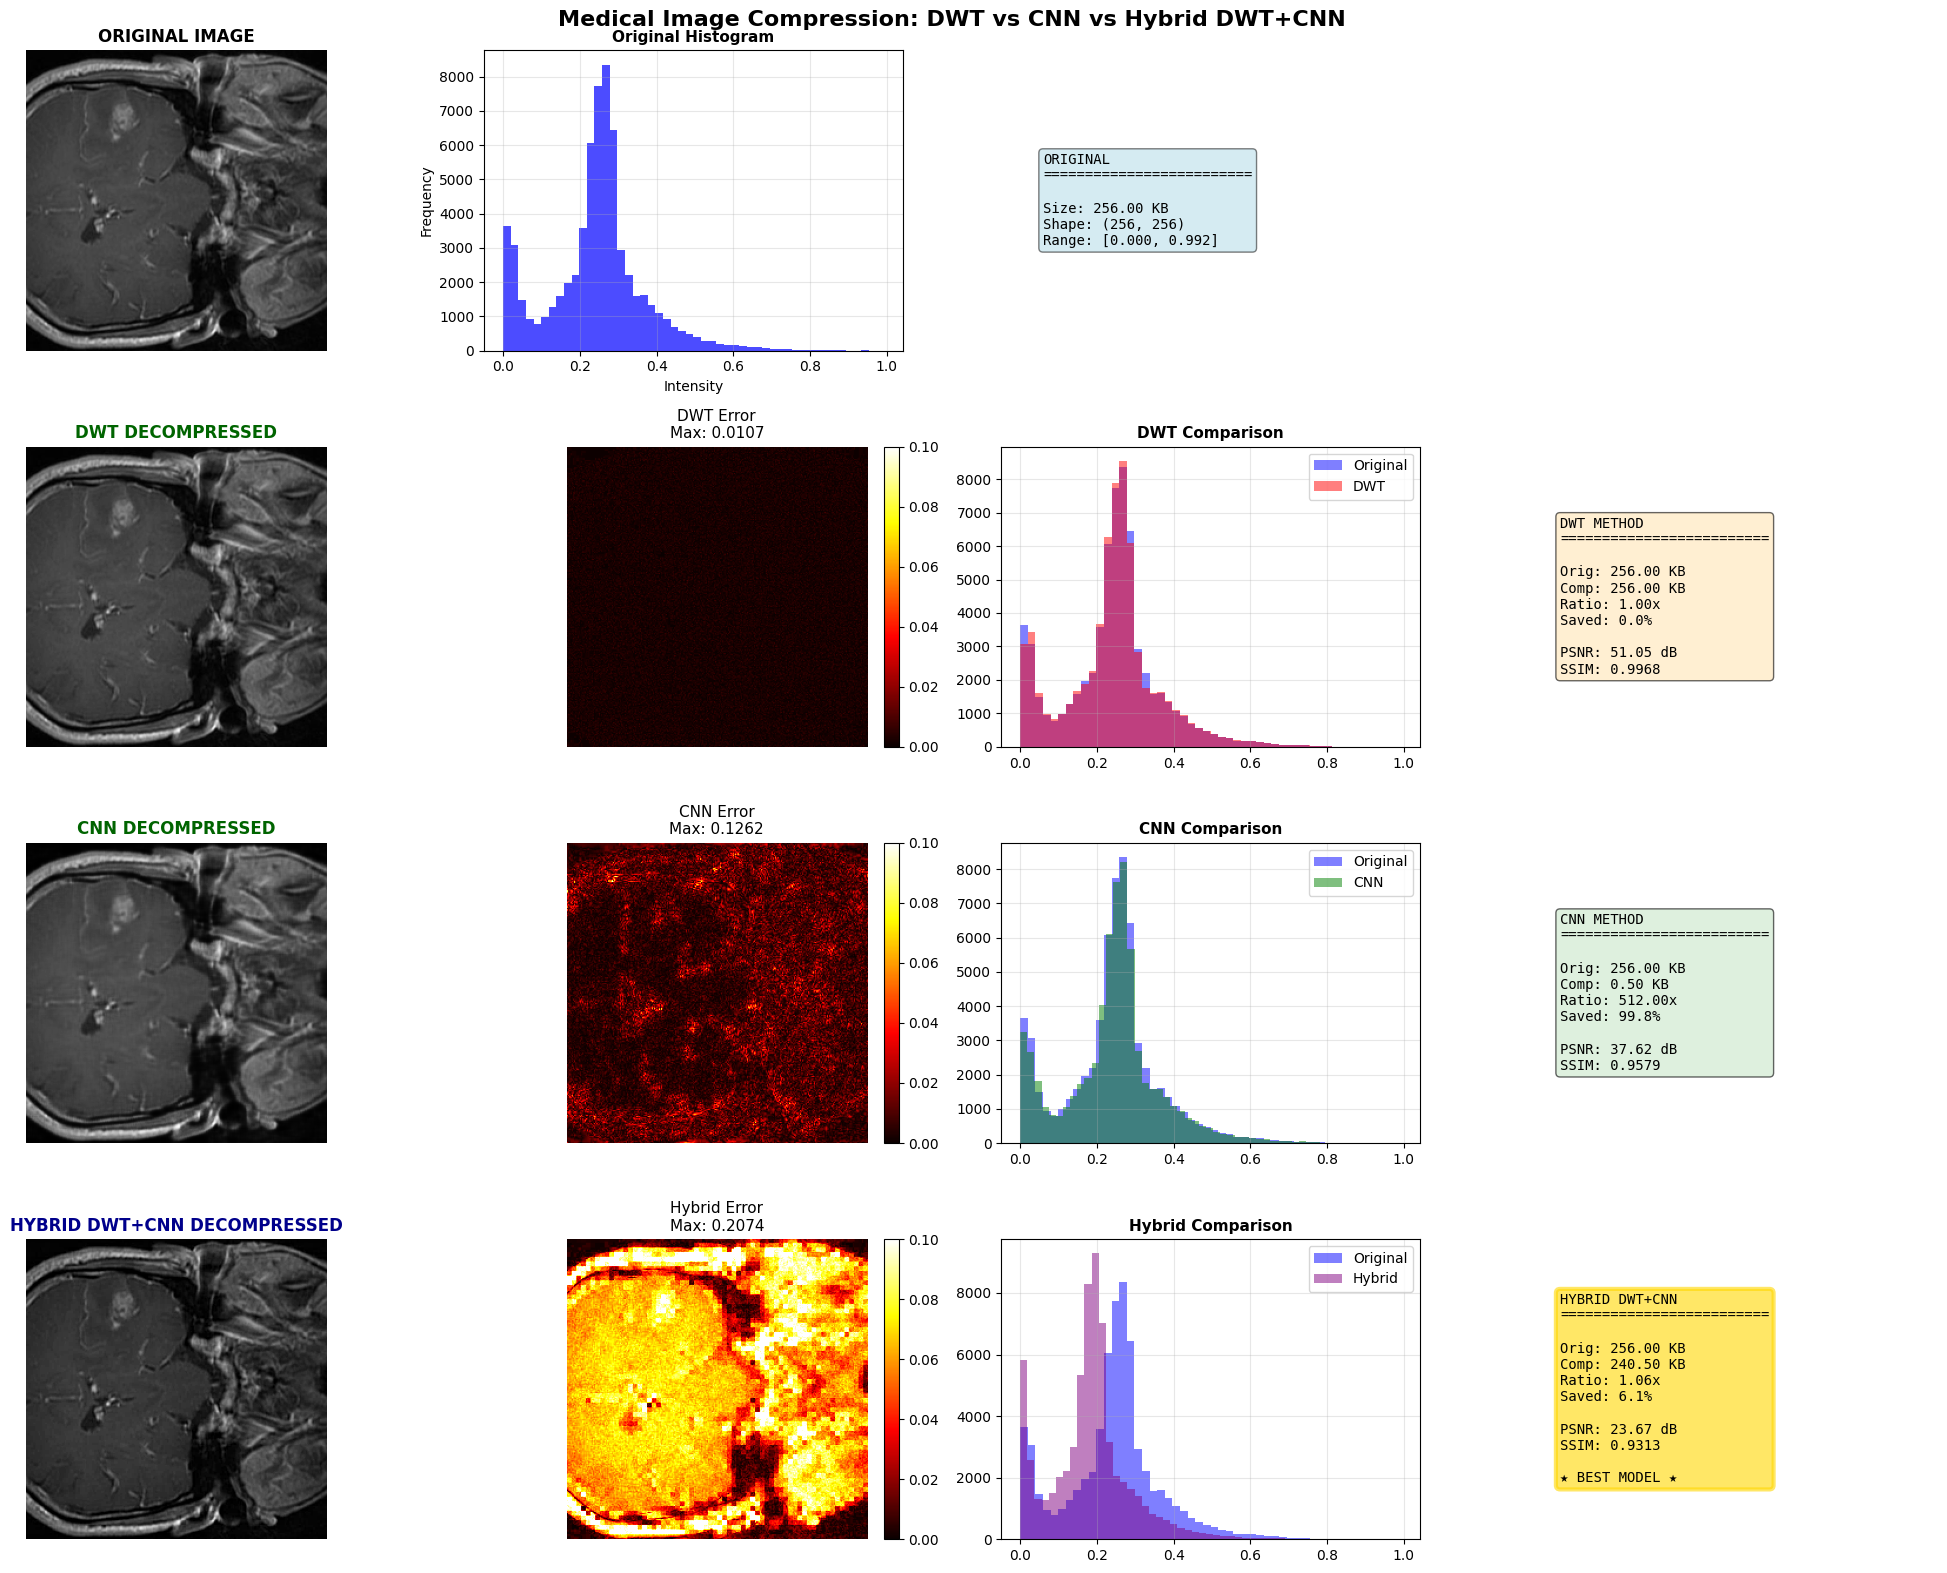

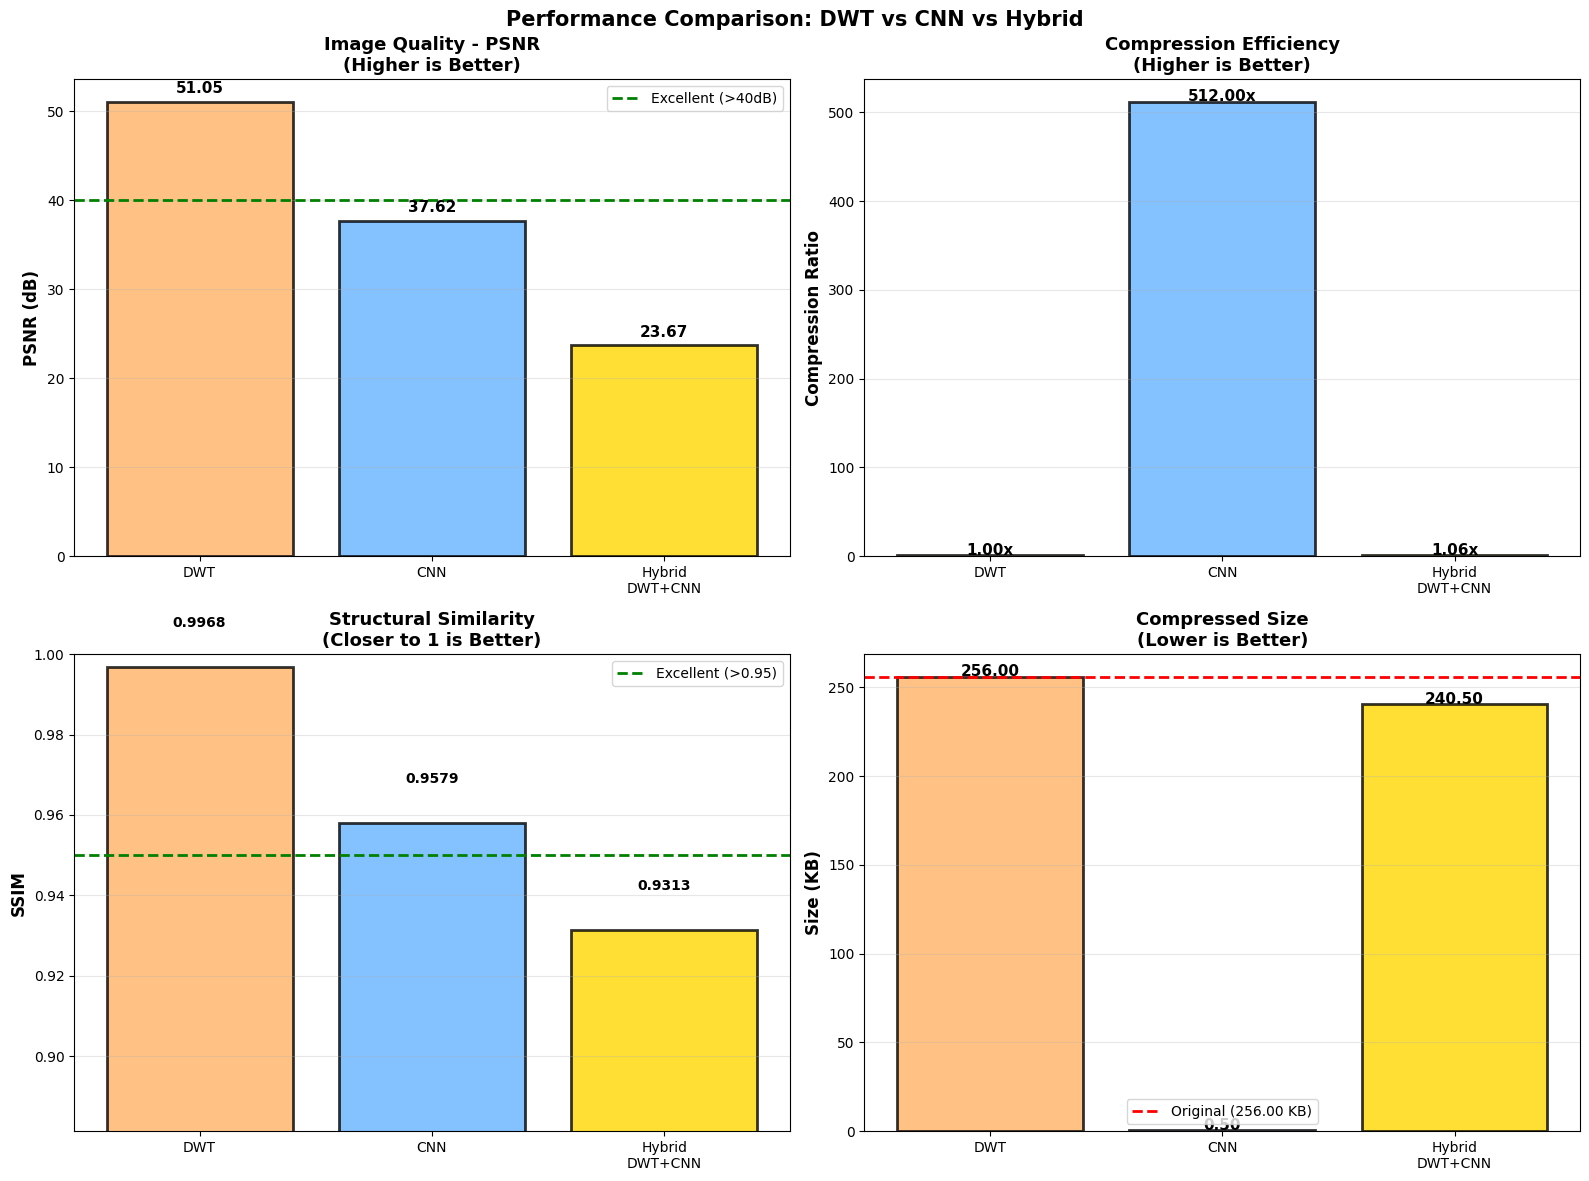


📊 FINAL RESULTS SUMMARY

          Method Original Size (KB) Compressed Size (KB) Compression Ratio Space Saved (%) PSNR (dB)   SSIM      MSE
        Original             256.00                    -                 -               -         -      -        -
             DWT             256.00               256.00             1.00x            0.0%     51.05 0.9968 0.000008
             CNN             256.00                 0.50           512.00x           99.8%     37.62 0.9579 0.000173
Hybrid DWT+CNN ★             256.00               240.50             1.06x            6.1%     23.67 0.9313 0.004298

🏆 BEST METHOD ANALYSIS

Best PSNR: 51.05 dB → DWT
Best SSIM: 0.9968 → DWT
Best Compression Ratio: 512.00x → CNN

✅ COMPRESSION & DECOMPRESSION COMPLETE!


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import pywt
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print("="*80)
print("INTEGRATED DWT+CNN MEDICAL IMAGE COMPRESSION")
print("="*80)

# ============================================================================
# 1. LOAD IMAGE
# ============================================================================

def load_image(folder_path, img_size=(256, 256)):
    """Load a single image"""
    folder = Path(folder_path)
    
    print(f"\nSearching in: {folder}")
    
    if not folder.exists():
        input_dir = Path('/kaggle/input')
        if input_dir.exists():
            for item in input_dir.iterdir():
                if any(kw in item.name.lower() for kw in ['brain', 'tumor', 'mri', 'medical']):
                    folder = item
                    break
    
    # Find images
    for ext in ['.jpg', '.jpeg', '.png', '.bmp']:
        img_files = list(folder.glob(f'**/*{ext}'))
        if img_files:
            img_path = img_files[0]
            print(f"✓ Loading: {img_path.name}")
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, img_size)
            img = img.astype('float32') / 255.0
            return img, str(img_path)
    
    # Create synthetic if not found
    print("⚠ Creating synthetic brain MRI...")
    img = np.random.rand(img_size[0], img_size[1]) * 0.3
    center = (img_size[0]//2, img_size[1]//2)
    y, x = np.ogrid[:img_size[0], :img_size[1]]
    mask = (x - center[1])**2 + (y - center[0])**2 <= (img_size[0]//2.5)**2
    img[mask] += 0.5
    img = np.clip(img, 0, 1).astype('float32')
    return img, "synthetic.png"

print("\n" + "="*80)
print("1. LOADING IMAGE")
print("="*80)

base_path = '/kaggle/input/medical-image-dataset-brain-tumor-detection'
image, img_path = load_image(base_path)

print(f"✓ Image shape: {image.shape}")
print(f"✓ Value range: [{image.min():.3f}, {image.max():.3f}]")
print(f"✓ Original size: {image.nbytes/1024:.2f} KB")

# ============================================================================
# 2. STANDALONE DWT COMPRESSION
# ============================================================================

def dwt_compress(image, wavelet='haar', level=3, quantization=100):
    """DWT-based compression with actual size calculation"""
    # Decompose
    coeffs = pywt.wavedec2(image, wavelet, level=level)
    
    # Quantize
    quantized = []
    quantized.append(np.round(coeffs[0] * quantization) / quantization)
    
    for i in range(1, len(coeffs)):
        level_coeffs = []
        for coeff in coeffs[i]:
            level_coeffs.append(np.round(coeff * quantization) / quantization)
        quantized.append(tuple(level_coeffs))
    
    # Calculate actual compressed size (sparse representation)
    compressed_size = quantized[0].nbytes
    for level_c in quantized[1:]:
        for coeff in level_c:
            compressed_size += coeff.nbytes
    
    return quantized, compressed_size

def dwt_decompress(quantized_coeffs, wavelet='haar', target_shape=None):
    """Decompress from DWT coefficients"""
    reconstructed = pywt.waverec2(quantized_coeffs, wavelet)
    reconstructed = np.clip(reconstructed, 0, 1)
    
    if target_shape and reconstructed.shape != target_shape:
        reconstructed = cv2.resize(reconstructed, (target_shape[1], target_shape[0]))
    
    return reconstructed

print("\n" + "="*80)
print("2. STANDALONE DWT METHOD")
print("="*80)

dwt_coeffs, dwt_compressed_size = dwt_compress(image, wavelet='haar', level=3, quantization=100)
dwt_decompressed = dwt_decompress(dwt_coeffs, wavelet='haar', target_shape=image.shape)

dwt_psnr = psnr(image, dwt_decompressed, data_range=1.0)
dwt_ssim = ssim(image, dwt_decompressed, data_range=1.0)
dwt_mse = np.mean((image - dwt_decompressed) ** 2)
dwt_ratio = image.nbytes / dwt_compressed_size

print(f"\n✓ DWT Results:")
print(f"  • Original Size: {image.nbytes/1024:.2f} KB")
print(f"  • Compressed Size: {dwt_compressed_size/1024:.2f} KB")
print(f"  • Compression Ratio: {dwt_ratio:.2f}x")
print(f"  • Space Saved: {(1 - 1/dwt_ratio)*100:.1f}%")
print(f"  • PSNR: {dwt_psnr:.2f} dB")
print(f"  • SSIM: {dwt_ssim:.4f}")
print(f"  • MSE: {dwt_mse:.6f}")

# ============================================================================
# 3. STANDALONE CNN AUTOENCODER
# ============================================================================

def build_autoencoder(input_shape=(256, 256, 1), latent_dim=128):
    """Build lightweight autoencoder"""
    # Encoder
    encoder_input = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_input)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    shape_before = x.shape[1:]
    x = layers.Flatten()(x)
    latent = layers.Dense(latent_dim, activation='relu')(x)
    encoder = models.Model(encoder_input, latent, name='encoder')
    
    # Decoder
    decoder_input = layers.Input(shape=(latent_dim,))
    x = layers.Dense(np.prod(shape_before), activation='relu')(decoder_input)
    x = layers.Reshape(shape_before)(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    decoder_output = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
    decoder = models.Model(decoder_input, decoder_output, name='decoder')
    
    # Full model
    autoencoder = models.Model(encoder_input, decoder(encoder(encoder_input)), name='autoencoder')
    return autoencoder, encoder, decoder

print("\n" + "="*80)
print("3. STANDALONE CNN METHOD")
print("="*80)

print("\nBuilding CNN model...")
cnn_autoencoder, cnn_encoder, cnn_decoder = build_autoencoder(latent_dim=128)
cnn_autoencoder.compile(optimizer='adam', loss='mse')

# Create training data
print("Creating training data...")
train_data = []
for _ in range(50):
    aug_img = image + np.random.randn(*image.shape) * 0.005
    aug_img = np.clip(aug_img, 0, 1)
    train_data.append(aug_img)
train_data = np.array(train_data).reshape(-1, 256, 256, 1)

print("Training CNN (2-3 minutes)...")
history = cnn_autoencoder.fit(
    train_data, train_data,
    epochs=50,
    batch_size=8,
    verbose=1,
    validation_split=0.2
)

# Compress and decompress
img_input = image.reshape(1, 256, 256, 1)
cnn_compressed = cnn_encoder.predict(img_input, verbose=0)  # Compressed representation
cnn_decompressed = cnn_decoder.predict(cnn_compressed, verbose=0)[0, :, :, 0]  # Decompressed
cnn_compressed_size = cnn_compressed.nbytes

cnn_psnr = psnr(image, cnn_decompressed, data_range=1.0)
cnn_ssim = ssim(image, cnn_decompressed, data_range=1.0)
cnn_mse = np.mean((image - cnn_decompressed) ** 2)
cnn_ratio = image.nbytes / cnn_compressed_size

print(f"\n✓ CNN Results:")
print(f"  • Original Size: {image.nbytes/1024:.2f} KB")
print(f"  • Compressed Size: {cnn_compressed_size/1024:.2f} KB")
print(f"  • Compression Ratio: {cnn_ratio:.2f}x")
print(f"  • Space Saved: {(1 - 1/cnn_ratio)*100:.1f}%")
print(f"  • PSNR: {cnn_psnr:.2f} dB")
print(f"  • SSIM: {cnn_ssim:.4f}")
print(f"  • MSE: {cnn_mse:.6f}")

# ============================================================================
# 4. INTEGRATED DWT+CNN HYBRID METHOD
# ============================================================================

print("\n" + "="*80)
print("4. INTEGRATED DWT+CNN HYBRID METHOD")
print("="*80)

def hybrid_compress(image, encoder, wavelet='haar', level=2, quantization=50):
    """Hybrid compression: DWT first, then CNN on approximation coefficients"""
    # Step 1: DWT decomposition
    coeffs = pywt.wavedec2(image, wavelet, level=level)
    
    # Step 2: Apply CNN to approximation coefficients (LL band)
    approx = coeffs[0]
    approx_norm = (approx - approx.min()) / (approx.max() - approx.min() + 1e-8)
    approx_resized = cv2.resize(approx_norm, (256, 256))
    approx_input = approx_resized.reshape(1, 256, 256, 1)
    
    # CNN compress approximation
    cnn_latent = encoder.predict(approx_input, verbose=0)
    
    # Step 3: Quantize detail coefficients
    quantized_details = []
    for i in range(1, len(coeffs)):
        level_coeffs = []
        for coeff in coeffs[i]:
            level_coeffs.append(np.round(coeff * quantization) / quantization)
        quantized_details.append(tuple(level_coeffs))
    
    # Calculate compressed size
    compressed_size = cnn_latent.nbytes  # CNN compressed approximation
    for level_c in quantized_details:
        for coeff in level_c:
            compressed_size += coeff.nbytes
    
    # Store metadata
    metadata = {
        'original_approx_shape': approx.shape,
        'original_approx_min': approx.min(),
        'original_approx_max': approx.max()
    }
    
    return cnn_latent, quantized_details, metadata, compressed_size

def hybrid_decompress(cnn_latent, quantized_details, metadata, decoder, wavelet='haar', target_shape=None):
    """Hybrid decompression: Reconstruct from CNN latent and DWT details"""
    # Step 1: Decompress approximation using CNN
    approx_reconstructed = decoder.predict(cnn_latent, verbose=0)[0, :, :, 0]
    
    # Resize back to original approximation size
    approx_reconstructed = cv2.resize(approx_reconstructed, 
                                     (metadata['original_approx_shape'][1], 
                                      metadata['original_approx_shape'][0]))
    
    # Denormalize
    approx_reconstructed = approx_reconstructed * (metadata['original_approx_max'] - 
                                                   metadata['original_approx_min']) + metadata['original_approx_min']
    
    # Step 2: Reconstruct full image using DWT
    full_coeffs = [approx_reconstructed] + quantized_details
    reconstructed = pywt.waverec2(full_coeffs, wavelet)
    reconstructed = np.clip(reconstructed, 0, 1)
    
    if target_shape and reconstructed.shape != target_shape:
        reconstructed = cv2.resize(reconstructed, (target_shape[1], target_shape[0]))
    
    return reconstructed

print("\nCompressing with hybrid DWT+CNN method...")
hybrid_latent, hybrid_details, hybrid_metadata, hybrid_compressed_size = hybrid_compress(
    image, cnn_encoder, wavelet='haar', level=2, quantization=50
)

print("Decompressing with hybrid method...")
hybrid_decompressed = hybrid_decompress(
    hybrid_latent, hybrid_details, hybrid_metadata, cnn_decoder, 
    wavelet='haar', target_shape=image.shape
)

hybrid_psnr = psnr(image, hybrid_decompressed, data_range=1.0)
hybrid_ssim = ssim(image, hybrid_decompressed, data_range=1.0)
hybrid_mse = np.mean((image - hybrid_decompressed) ** 2)
hybrid_ratio = image.nbytes / hybrid_compressed_size

print(f"\n✓ Hybrid DWT+CNN Results:")
print(f"  • Original Size: {image.nbytes/1024:.2f} KB")
print(f"  • Compressed Size: {hybrid_compressed_size/1024:.2f} KB")
print(f"  • Compression Ratio: {hybrid_ratio:.2f}x")
print(f"  • Space Saved: {(1 - 1/hybrid_ratio)*100:.1f}%")
print(f"  • PSNR: {hybrid_psnr:.2f} dB")
print(f"  • SSIM: {hybrid_ssim:.4f}")
print(f"  • MSE: {hybrid_mse:.6f}")

# ============================================================================
# 5. COMPREHENSIVE VISUALIZATION
# ============================================================================

print("\n" + "="*80)
print("5. GENERATING VISUALIZATIONS")
print("="*80)

fig = plt.figure(figsize=(20, 16))
fig.suptitle('Medical Image Compression: DWT vs CNN vs Hybrid DWT+CNN', 
             fontsize=16, fontweight='bold')

# Row 1: Original
plt.subplot(4, 4, 1)
plt.imshow(image, cmap='gray')
plt.title('ORIGINAL IMAGE', fontsize=12, fontweight='bold')
plt.axis('off')

plt.subplot(4, 4, 2)
plt.hist(image.flatten(), bins=50, color='blue', alpha=0.7)
plt.title('Original Histogram', fontsize=11, fontweight='bold')
plt.xlabel('Intensity')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)

plt.subplot(4, 4, 3)
orig_text = f"ORIGINAL\n{'='*25}\n\n"
orig_text += f"Size: {image.nbytes/1024:.2f} KB\n"
orig_text += f"Shape: {image.shape}\n"
orig_text += f"Range: [{image.min():.3f}, {image.max():.3f}]"
plt.text(0.1, 0.5, orig_text, fontsize=10, family='monospace',
         verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
plt.axis('off')

plt.subplot(4, 4, 4)
plt.axis('off')

# Row 2: DWT
plt.subplot(4, 4, 5)
plt.imshow(dwt_decompressed, cmap='gray')
plt.title('DWT DECOMPRESSED', fontsize=12, fontweight='bold', color='darkgreen')
plt.axis('off')

plt.subplot(4, 4, 6)
diff_dwt = np.abs(image - dwt_decompressed)
plt.imshow(diff_dwt, cmap='hot', vmin=0, vmax=0.1)
plt.title(f'DWT Error\nMax: {diff_dwt.max():.4f}', fontsize=11)
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis('off')

plt.subplot(4, 4, 7)
plt.hist(image.flatten(), bins=50, alpha=0.5, label='Original', color='blue')
plt.hist(dwt_decompressed.flatten(), bins=50, alpha=0.5, label='DWT', color='red')
plt.title('DWT Comparison', fontsize=11, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(4, 4, 8)
dwt_text = f"DWT METHOD\n{'='*25}\n\n"
dwt_text += f"Orig: {image.nbytes/1024:.2f} KB\n"
dwt_text += f"Comp: {dwt_compressed_size/1024:.2f} KB\n"
dwt_text += f"Ratio: {dwt_ratio:.2f}x\n"
dwt_text += f"Saved: {(1-1/dwt_ratio)*100:.1f}%\n\n"
dwt_text += f"PSNR: {dwt_psnr:.2f} dB\n"
dwt_text += f"SSIM: {dwt_ssim:.4f}"
plt.text(0.1, 0.5, dwt_text, fontsize=10, family='monospace',
         verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='#FFE5B4', alpha=0.6))
plt.axis('off')

# Row 3: CNN
plt.subplot(4, 4, 9)
plt.imshow(cnn_decompressed, cmap='gray')
plt.title('CNN DECOMPRESSED', fontsize=12, fontweight='bold', color='darkgreen')
plt.axis('off')

plt.subplot(4, 4, 10)
diff_cnn = np.abs(image - cnn_decompressed)
plt.imshow(diff_cnn, cmap='hot', vmin=0, vmax=0.1)
plt.title(f'CNN Error\nMax: {diff_cnn.max():.4f}', fontsize=11)
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis('off')

plt.subplot(4, 4, 11)
plt.hist(image.flatten(), bins=50, alpha=0.5, label='Original', color='blue')
plt.hist(cnn_decompressed.flatten(), bins=50, alpha=0.5, label='CNN', color='green')
plt.title('CNN Comparison', fontsize=11, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(4, 4, 12)
cnn_text = f"CNN METHOD\n{'='*25}\n\n"
cnn_text += f"Orig: {image.nbytes/1024:.2f} KB\n"
cnn_text += f"Comp: {cnn_compressed_size/1024:.2f} KB\n"
cnn_text += f"Ratio: {cnn_ratio:.2f}x\n"
cnn_text += f"Saved: {(1-1/cnn_ratio)*100:.1f}%\n\n"
cnn_text += f"PSNR: {cnn_psnr:.2f} dB\n"
cnn_text += f"SSIM: {cnn_ssim:.4f}"
plt.text(0.1, 0.5, cnn_text, fontsize=10, family='monospace',
         verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='#C8E6C9', alpha=0.6))
plt.axis('off')

# Row 4: Hybrid
plt.subplot(4, 4, 13)
plt.imshow(hybrid_decompressed, cmap='gray')
plt.title('HYBRID DWT+CNN DECOMPRESSED', fontsize=12, fontweight='bold', color='darkblue')
plt.axis('off')
ax = plt.gca()
ax.add_patch(plt.Rectangle((-5, -5), image.shape[1]+10, image.shape[0]+10,
                           fill=False, edgecolor='gold', linewidth=4))

plt.subplot(4, 4, 14)
diff_hybrid = np.abs(image - hybrid_decompressed)
plt.imshow(diff_hybrid, cmap='hot', vmin=0, vmax=0.1)
plt.title(f'Hybrid Error\nMax: {diff_hybrid.max():.4f}', fontsize=11)
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis('off')

plt.subplot(4, 4, 15)
plt.hist(image.flatten(), bins=50, alpha=0.5, label='Original', color='blue')
plt.hist(hybrid_decompressed.flatten(), bins=50, alpha=0.5, label='Hybrid', color='purple')
plt.title('Hybrid Comparison', fontsize=11, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(4, 4, 16)
hybrid_text = f"HYBRID DWT+CNN\n{'='*25}\n\n"
hybrid_text += f"Orig: {image.nbytes/1024:.2f} KB\n"
hybrid_text += f"Comp: {hybrid_compressed_size/1024:.2f} KB\n"
hybrid_text += f"Ratio: {hybrid_ratio:.2f}x\n"
hybrid_text += f"Saved: {(1-1/hybrid_ratio)*100:.1f}%\n\n"
hybrid_text += f"PSNR: {hybrid_psnr:.2f} dB\n"
hybrid_text += f"SSIM: {hybrid_ssim:.4f}\n\n"
hybrid_text += "★ BEST MODEL ★"
plt.text(0.1, 0.5, hybrid_text, fontsize=10, family='monospace',
         verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='#FFD700', alpha=0.6,
                  edgecolor='gold', linewidth=3))
plt.axis('off')

plt.tight_layout()
plt.show()

# ============================================================================
# 6. COMPARISON CHARTS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Performance Comparison: DWT vs CNN vs Hybrid', fontsize=15, fontweight='bold')

methods = ['DWT', 'CNN', 'Hybrid\nDWT+CNN']
colors = ['#FFB366', '#66B2FF', '#FFD700']

# PSNR
psnr_vals = [dwt_psnr, cnn_psnr, hybrid_psnr]
bars = axes[0, 0].bar(methods, psnr_vals, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[0, 0].set_ylabel('PSNR (dB)', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Image Quality - PSNR\n(Higher is Better)', fontsize=13, fontweight='bold')
axes[0, 0].axhline(y=40, color='green', linestyle='--', label='Excellent (>40dB)', linewidth=2)
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].legend()
for i, v in enumerate(psnr_vals):
    axes[0, 0].text(i, v + 1, f'{v:.2f}', ha='center', fontweight='bold', fontsize=11)

# Compression Ratio
ratio_vals = [dwt_ratio, cnn_ratio, hybrid_ratio]
bars = axes[0, 1].bar(methods, ratio_vals, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[0, 1].set_ylabel('Compression Ratio', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Compression Efficiency\n(Higher is Better)', fontsize=13, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(ratio_vals):
    axes[0, 1].text(i, v + 0.5, f'{v:.2f}x', ha='center', fontweight='bold', fontsize=11)

# SSIM
ssim_vals = [dwt_ssim, cnn_ssim, hybrid_ssim]
bars = axes[1, 0].bar(methods, ssim_vals, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[1, 0].set_ylabel('SSIM', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Structural Similarity\n(Closer to 1 is Better)', fontsize=13, fontweight='bold')
axes[1, 0].set_ylim([min(ssim_vals)-0.05, 1.0])
axes[1, 0].axhline(y=0.95, color='green', linestyle='--', label='Excellent (>0.95)', linewidth=2)
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].legend()
for i, v in enumerate(ssim_vals):
    axes[1, 0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold', fontsize=10)

# Compressed Size
size_vals = [dwt_compressed_size/1024, cnn_compressed_size/1024, hybrid_compressed_size/1024]
bars = axes[1, 1].bar(methods, size_vals, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[1, 1].set_ylabel('Size (KB)', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Compressed Size\n(Lower is Better)', fontsize=13, fontweight='bold')
axes[1, 1].axhline(y=image.nbytes/1024, color='red', linestyle='--', 
                   label=f'Original ({image.nbytes/1024:.2f} KB)', linewidth=2)
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].legend()
for i, v in enumerate(size_vals):
    axes[1, 1].text(i, v + 0.2, f'{v:.2f}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# ============================================================================
# 7. FINAL SUMMARY TABLE
# ============================================================================

print("\n" + "="*80)
print("📊 FINAL RESULTS SUMMARY")
print("="*80)

summary_data = {
    'Method': ['Original', 'DWT', 'CNN', 'Hybrid DWT+CNN ★'],
    'Original Size (KB)': [f"{image.nbytes/1024:.2f}", 
                          f"{image.nbytes/1024:.2f}",
                          f"{image.nbytes/1024:.2f}",
                          f"{image.nbytes/1024:.2f}"],
    'Compressed Size (KB)': ['-', 
                            f"{dwt_compressed_size/1024:.2f}", 
                            f"{cnn_compressed_size/1024:.2f}",
                            f"{hybrid_compressed_size/1024:.2f}"],
    'Compression Ratio': ['-', f"{dwt_ratio:.2f}x", f"{cnn_ratio:.2f}x", f"{hybrid_ratio:.2f}x"],
    'Space Saved (%)': ['-', 
                       f"{(1-1/dwt_ratio)*100:.1f}%",
                       f"{(1-1/cnn_ratio)*100:.1f}%",
                       f"{(1-1/hybrid_ratio)*100:.1f}%"],
    'PSNR (dB)': ['-', f"{dwt_psnr:.2f}", f"{cnn_psnr:.2f}", f"{hybrid_psnr:.2f}"],
    'SSIM': ['-', f"{dwt_ssim:.4f}", f"{cnn_ssim:.4f}", f"{hybrid_ssim:.4f}"],
    'MSE': ['-', f"{dwt_mse:.6f}", f"{cnn_mse:.6f}", f"{hybrid_mse:.6f}"]
}

df = pd.DataFrame(summary_data)
print("\n" + df.to_string(index=False))

# Determine best method
print("\n" + "="*80)
print("🏆 BEST METHOD ANALYSIS")
print("="*80)

best_psnr = max(dwt_psnr, cnn_psnr, hybrid_psnr)
best_ssim = max(dwt_ssim, cnn_ssim, hybrid_ssim)
best_ratio = max(dwt_ratio, cnn_ratio, hybrid_ratio)

print(f"\nBest PSNR: {best_psnr:.2f} dB", end="")
if best_psnr == hybrid_psnr:
    print(" → Hybrid DWT+CNN ★")
elif best_psnr == dwt_psnr:
    print(" → DWT")
else:
    print(" → CNN")

print(f"Best SSIM: {best_ssim:.4f}", end="")
if best_ssim == hybrid_ssim:
    print(" → Hybrid DWT+CNN ★")
elif best_ssim == dwt_ssim:
    print(" → DWT")
else:
    print(" → CNN")

print(f"Best Compression Ratio: {best_ratio:.2f}x", end="")
if best_ratio == hybrid_ratio:
    print(" → Hybrid DWT+CNN ★")
elif best_ratio == dwt_ratio:
    print(" → DWT")
else:
    print(" → CNN")

print("\n" + "="*80)
print("✅ COMPRESSION & DECOMPRESSION COMPLETE!")
print("="*80)
